In [1]:
suppressPackageStartupMessages({
    library(ArchR) 
    library(data.table)
    library(purrr)
    library(parallel)
    library(dplyr)
    library(ggpubr)
    library(BSgenome)
    library(biomaRt)
    library(BSgenome.Ocuniculus.NCBI.oryCun2)
    library(GenomicFeatures)
    library(compEpiTools)
    library(GenomeInfoDb)
    library(stringi)
    library(AnnotationHub)
})

options(repr.plot.width=15, repr.plot.height=8)


groupGOTerms: 	GOBPTerm, GOMFTerm, GOCCTerm environments built.

No methods found in package 'BiocGenerics' for requests: 'clusterApplyLB', 'clusterEvalQ' when loading 'methylPipe'

No methods found in package 'BiocGenerics' for requests: 'clusterApplyLB', 'clusterEvalQ' when loading 'compEpiTools'



In [3]:
# I/O
io = list()
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC'
io$output.directory <- file.path(io$basedir,"ArchR")
setwd(io$output.directory)

In [4]:
# ArchR options
addArchRThreads(threads = 1) 

Setting default number of Parallel threads to 1.



In [5]:
# Create genome annotation
genomeAnnotation <- createGenomeAnnotation(genome = BSgenome.Ocuniculus.NCBI.oryCun2)

#important as rabbit chromosome dont have the 'chr' prefix
addArchRChrPrefix(chrPrefix = FALSE)

# Create a gene annotation using Txdb file
rabbit_txdb <- makeTxDbFromBiomart(biomart="ensembl", dataset="ocuniculus_gene_ensembl")

taxid = taxonomyId(rabbit_txdb)
## If we don't have a package, then lets get the taxIds and AHIds
        ## for the hub objects
        loadNamespace("AnnotationHub")
        ah <- AnnotationHub::AnnotationHub()
        ah <- subset(ah, ah$rdataclass=='OrgDb') 
        mc <- mcols(ah)[,'taxonomyid', drop=FALSE]
        ## Then just get the object
        AHID <- rownames(mc[mc$taxonomyid==taxid,,drop=FALSE])
        rabbit_OrgDb <- ah[[AHID[2]]]

#rabbit_txdb
geneAnnotation <- createGeneAnnotation(
  TxDb  = rabbit_txdb,
    OrgDb =rabbit_OrgDb,
  TSS = TSS(rabbit_txdb), 
  exons = exons(rabbit_txdb)
)

seqlevelsStyle(genomeAnnotation$chromSizes) <- 'NCBI'

Getting genome..

Getting chromSizes..

Getting blacklist..

Blacklist not downloaded! Continuing without, be careful for downstream biases..

ArchR is now disabling the requirement of chromosome prefix = 'chr'

Warning message:
"Ensembl will soon enforce the use of https.
Ensure the 'host' argument includes "https://""
Ensembl site unresponsive, trying uswest mirror

Ensembl site unresponsive, trying useast mirror

Ensembl site unresponsive, trying useast mirror

Ensembl site unresponsive, trying asia mirror

Download and preprocess the 'transcripts' data frame ... 
OK

Download and preprocess the 'chrominfo' data frame ... 
OK

Download and preprocess the 'splicings' data frame ... 
OK

Download and preprocess the 'genes' data frame ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
OK



<environment: namespace:AnnotationHub>

snapshotDate(): 2021-10-20

loading from cache

'select()' returned 1:1 mapping between keys and columns

Getting Genes..

Determined Annotation Style = ENSEMBL

Getting Exons..

Getting TSS..



In [6]:
ArrowFiles = list.files(io$output.directory, pattern ='arrow')

In [7]:
# Calculate doublet scores
doubScores <- addDoubletScores(
  input = ArrowFiles,
  k = 10, #Refers to how many cells near a "pseudo-doublet" to count.
  knnMethod = "UMAP", #Refers to the embedding to use for nearest neighbor search.
  LSIMethod = 1
)

ArchR logging to : ArchRLogs/ArchR-addDoubletScores-30b7736153ace-Date-2021-12-01_Time-10-56-07.log
If there is an issue, please report to github with logFile!

2021-12-01 10:56:07 : Batch Execution w/ safelapply!, 0 mins elapsed.

2021-12-01 10:56:07 : rabbit_BGRGP1 (1 of 8) :  Computing Doublet Statistics, 0.002 mins elapsed.

Warning message:
"The following arguments are not used: row.names"
Biased Clusters : 
Cluster16 


rabbit_BGRGP1 (1 of 8) : UMAP Projection R^2 = 0.99091

rabbit_BGRGP1 (1 of 8) : UMAP Projection R^2 = 0.99091



Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."


2021-12-01 11:03:41 : rabbit_BGRGP2 (2 of 8) :  Computing Doublet Statistics, 7.571 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

Warning message:
"The following arguments are not used: row.names"
rabbit_BGRGP2 (2 of 8) : UMAP Projection R^2 = 0.99478

rabbit_BGRGP2 (2 of 8) : UMAP Projection R^2 = 0.99478



Warning mes

In [8]:
proj <- ArchRProject(
  ArrowFiles = ArrowFiles, 
  outputDirectory = "Project",
  copyArrows = TRUE, #This is recommened so that you maintain an unaltered copy for later usage.
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : MT,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW020

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : MT,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW020

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : MT,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW0208

Validating Arrows...

Getting SampleNames...

1 
2 
3 
4 
5 
6 
7 
8 


Copying ArrowFiles to Ouptut Directory! If you want to save disk space set copyArrows = FALSE

1 
2 
3 
4 
5 
6 
7 
8 


Getting Cell Metadata...

1 
2 
3 
4 
5 
6 
7 
8 


Merging Cell Metadata...

Initializing ArchRProject...


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-==============

In [9]:
proj <- saveArchRProject(ArchRProj = proj)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

In [10]:
getAvailableMatrices(proj)

[1] "GeneScoreMatrix" "TileMatrix"

In [11]:
proj <- filterDoublets(ArchRProj = proj)

Filtering 1514 cells from ArchRProject!

	rabbit_BGRGP1 : 798 of 8937 (8.9%)

	rabbit_BGRGP2 : 107 of 3272 (3.3%)

	rabbit_BGRGP3 : 120 of 3474 (3.5%)

	rabbit_BGRGP4 : 27 of 1656 (1.6%)

	rabbit_BGRGP5 : 135 of 3683 (3.7%)

	rabbit_BGRGP6 : 124 of 3526 (3.5%)

	rabbit_BGRGP7 : 107 of 3279 (3.3%)

	rabbit_BGRGP8 : 96 of 3109 (3.1%)



In [12]:
# Create metadata
archR_metadata <- getCellColData(proj) %>%
  as.data.table(keep.rownames = T) %>% setnames("rn","cell") %>%
  .[,c("cell", "TSSEnrichment", "ReadsInTSS", "PromoterRatio", "NucleosomeRatio", "nFrags")] %>%
 #  .[,cell:=stringr::str_replace_all(cell,"#","_")] %>%
   .[,sample:=strsplit(cell,"#") %>% map_chr(1)]


#sample 1 is GD7
#sample 2 & 3 is GD8 (same pool, 2 samples submitted)
#sample 4 is GD9 YS
#samples5-8 are GD9, embryo proper 4 samples from the same embryo

stages = data.frame('sample' = c('rabbit_BGRGP1', 'rabbit_BGRGP2', 'rabbit_BGRGP3', 'rabbit_BGRGP4', 'rabbit_BGRGP5', 'rabbit_BGRGP6', 'rabbit_BGRGP7', 'rabbit_BGRGP8'),
                    'stage' = c('GD7', 'GD8', 'GD8', 'GD9_YS', 'GD9', 'GD9', 'GD9', 'GD9' ))

archR_metadata = merge(archR_metadata, stages, by='sample')

#############################
## Update ArchR's metadata ##
#############################

metadata.to.archR <- archR_metadata %>% 
  .[cell%in%rownames(proj)] %>% setkey(cell) %>% .[rownames(proj)] %>%
  as.data.frame() %>% tibble::column_to_rownames("cell")

stopifnot(all(metadata.to.archR$TSSEnrichment_atac == getCellColData(proj, "TSSEnrichment")[[1]]))

for (i in colnames(metadata.to.archR)) {
  proj <- addCellColData(
    proj,
    data = metadata.to.archR[[i]], 
    name = i,
    cells = rownames(metadata.to.archR),
    force = TRUE
  )
}

fwrite(archR_metadata, file.path(io$output.directory, 'metadata.txt.gz'), sep="\t", na="NA", quote=F)
saveArchRProject(proj)

Warning message in .local(x, row.names, optional, ...):
"Arguments in '...' ignored"
Overriding previous entry for TSSEnrichment

Overriding previous entry for ReadsInTSS

Overriding previous entry for PromoterRatio

Overriding previous entry for NucleosomeRatio

Overriding previous entry for nFrags

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /_

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(15): Sample TSSEnrichment ... sample stage
numberOfCells(1): 29422
medianTSS(1): 3.528
medianFrags(1): 30721.5

sample 1 is GD7

sample 2 & 3 is GD8 (same pool, 2 samples submitted)

sample 4 is GD9 YS

samples5-8 are GD9, embryo proper 4 samples from the same embryo

#### QC

In [13]:
suppressPackageStartupMessages({
    library(purrr)
    library(ggpubr)
})

io$archR.directory = file.path(io$output.directory, 'Project')
ArchRProject = suppressMessages(loadArchRProject(io$archR.directory))

In [14]:
# I/O
# io$metadata <- paste0(io$basedir,"/processed/atac/archR/sample_metadata_after_archR.txt.gz")
io$outdir <- file.path(io$output.directory,"qc")

# QC thresholds
opts = list()
opts$min.TSSEnrichment <- 0
opts$min.log_nFrags <- 11.75 # 2**11.75 ~ 3500
# opts$min.log_nFrags <- 11

opts$test <- FALSE

# Options
opts$samples <- c(
    'rabbit_BGRGP1',
    'rabbit_BGRGP2',
    'rabbit_BGRGP3',
    'rabbit_BGRGP4',
    'rabbit_BGRGP5',
    'rabbit_BGRGP6',
    'rabbit_BGRGP7',
    'rabbit_BGRGP8'
    )


########################
## Load cell metadata ##
########################
io$metadata <- file.path(io$output.directory, 'metadata.txt.gz')
sample_metadata <- fread(io$metadata)

#############
## Call QC ##
#############

sample_metadata %>%
    .[,pass_atacQC:=TSSEnrichment>=opts$min.TSSEnrichment & log2(nFrags)>=opts$min.log_nFrags] %>%
    .[is.na(pass_atacQC),pass_atacQC:=FALSE]

fwrite(sample_metadata, file.path(io$output.directory, 'metadata_qc.txt.gz'), sep="\t", na="NA", quote=F)


##################
## Subset ArchR ##
##################

if (opts$test) {
  
  # Subset cells for faster computations
  cells.to.use <- split(ArchRProject$cellNames,ArchRProject$sample) %>% map(~ head(.,n=1000)) %>% unlist
  
  # Subset features for faster computations
  tss.granges <- getTSS(ArchRProject)
  tss.granges <- tss.granges[seqnames(tss.granges)%in%c("chr1","chr2","chr3")]
  ArchRProject <- ArchRProject[cells.to.use,]
}

#########################
## Plot TSS Enrichment ##
#########################

tss.granges <- getTSS(ArchRProject)
if (opts$test) tss.granges <- tss.granges[seqnames(tss.granges)%in%c("chr1","chr2","chr3")]

to.plot.tss <- opts$samples %>% map(function(i) {
  plotTSSEnrichment(
    ArchRProj = ArchRProject[ArchRProject$Sample==i,], 
    groupBy = "Sample", 
    returnDF = TRUE,
    TSS = tss.granges
  ) %>% as.data.table %>% return
}) %>% rbindlist %>% 
  setnames("group","sample") %>% 
  melt(id.vars=c("sample","x"))

# For some reason this doesnt work........
fwrite(to.plot.tss, sprintf("%s/qc_TSSenrichment.txt.gz",io$outdir))

to.plot.tss <- fread(sprintf("%s/qc_TSSenrichment.txt.gz",io$outdir)) %>% 
  merge(unique(sample_metadata[,c("stage","sample")]),by="sample") %>%
  .[,.(value=mean(value)), by = c("stage","x","variable")]

p <- ggline(to.plot.tss[variable=="normValue"], x="x", y="value", plot_type="l", color="stage") +
  facet_wrap(~stage, scales="fixed", nrow=1) +
  #scale_colour_manual(values=opts$stage.colors) +
  # scale_x_continuous(breaks=seq(-2000,2000,1000)) +
  labs(x="Distance from TSS (bp)", y="TSS enrichment (normalised)") +
  theme(
    axis.text = element_text(size=rel(0.5)),
    axis.title = element_text(size=rel(0.75)),
    legend.position = "none",
    legend.title = element_blank()
  )

pdf(sprintf("%s/qc_TSSenrichment.pdf",io$outdir), width=8, height=4)
print(p)
dev.off()

#####################################
## Plot Fragment size distribution ##
#####################################

to.plot.fragmentsize <- plotFragmentSizes(ArchRProject, groupBy = "Sample", returnDF=T) %>% 
  as.data.table %>% setnames("group","sample")
fwrite(to.plot.fragmentsize, sprintf("%s/qc_FragmentSizeDistribution.txt.gz",io$outdir))

# to.plot <- to.plot.fragmentsize %>% .[variable=="fragmentPercent"] %>% .[,fragmentSize:=1:.N,by="sample"] %>% setnames("value","fragmentPercent") %>% .[,variable:=NULL]

to.plot.fragmentsize <- fread(sprintf("%s/qc_FragmentSizeDistribution.txt.gz",io$outdir)) %>% 
  merge(unique(sample_metadata[,c("stage","sample")]),by="sample") %>%
  .[,.(fragmentPercent=mean(fragmentPercent)), by = c("stage","fragmentSize")]

# to.plot.fragmentsize2 <- to.plot.fragmentsize %>% dcast(sample~variable, value.var="value")
p <- ggline(to.plot.fragmentsize, x="fragmentSize", y="fragmentPercent", plot_type="l", color="stage") +
  facet_wrap(~stage, scales="fixed", nrow=1) +
  scale_x_continuous(breaks=seq(125,750,125)) +
 # scale_colour_manual(values=opts$stage.colors) +
  labs(x="Fragment Size (bp)", y="Percentage of fragments (%)") +
  theme(
    axis.text = element_text(size=rel(0.55)),
    axis.title = element_text(size=rel(0.75)),
    legend.position = "right",
    legend.title = element_blank()
  )

pdf(sprintf("%s/qc_FragmentSizeDistribution.pdf",io$outdir), width=8, height=4)
print(p)
dev.off()

###########################################
## Plot summary statistics of QC metrics ##
###########################################

# Histograms

to.plot <- sample_metadata %>%
  .[!is.na(nFrags)] %>%
  .[,log_nFrags:=log10(nFrags)] %>%
  # melt(id.vars=c("sample","cell"), measure.vars=c("TSSEnrichment_atac","log_nFrags","BlacklistRatio_atac"))
  melt(id.vars=c("sample","cell"), measure.vars=c("TSSEnrichment","log_nFrags"))

# tmp <- data.table(
#   variable = c("TSSEnrichment_atac", "log_nFrags", "BlacklistRatio_atac"),
#   value = c(opts$min.TSSEnrichment, opts$min.log_nFrags, opts$max.BlacklistRatio)
# )
tmp <- data.table(
  variable = c("TSSEnrichment", "log_nFrags"),
  value = c(opts$min.TSSEnrichment, opts$min.log_nFrags)
)
# p <- gghistogram(to.plot, x="value", fill="sample", bins=50) +
p <- gghistogram(to.plot, x="value", y="..density..", bins=70) +
  geom_vline(aes(xintercept=value), linetype="dashed", data=tmp) +
  facet_wrap(~variable, scales="free") +
  theme(
    axis.text =  element_text(size=rel(0.8)),
    axis.title.x = element_blank(),
    legend.position = "right",
    legend.text = element_text(size=rel(0.5))
  )
pdf(sprintf("%s/qc_metrics_histogram2.pdf",io$outdir), width=8, height=5)
print(p)
dev.off()



to.plot <- sample_metadata %>%
  .[pass_atacQC==TRUE & TSSEnrichment<21] %>%
  .[TSSEnrichment<21] %>%
  .[,log_nFrags:=log10(nFrags)] %>%
  # melt(id.vars=c("sample","cell"), measure.vars=c("TSSEnrichment_atac","log_nFrags","BlacklistRatio_atac"))
  melt(id.vars=c("sample","cell","stage"), measure.vars=c("TSSEnrichment","log_nFrags"))

# Boxplots
p <- ggboxplot(to.plot, x="sample", y="value", fill="stage", outlier.shape=NA) +
 # scale_fill_manual(values=opts$stage.colors) +
  facet_wrap(~variable, scales="free_y") +
  theme(
    # legend.position = "none",
    legend.title = element_blank(),
    # axis.text.x = element_text(colour="black",size=rel(0.65), angle=20, hjust=1, vjust=1),  
    axis.text.x = element_text(colour="black",size=rel(0.65)),  
    axis.text.y = element_text(colour="black",size=rel(0.75)),  
    axis.title.x = element_blank()
  )
pdf(sprintf("%s/qc_metrics_boxplot.pdf",io$outdir), width=10, height=6)
print(p)
dev.off()


#########################################################
## Plot fraction of cells that pass QC for each sample ##
#########################################################

to.plot <- sample_metadata %>%
  .[,mean(pass_atacQC),by="sample"]

p <- ggbarplot(to.plot, x="sample", y="V1", fill="gray70") +
    labs(x="", y="Fraction of cells that pass QC") +
  coord_cartesian(ylim=c(0,1)) +
    theme(
        axis.text.x = element_text(colour="black",size=rel(0.65), angle=20, hjust=1, vjust=1),  
    )

# pdf(sprintf("%s/qc_metrics_barplot.pdf",io$outdir), width=9, height=7)
pdf(sprintf("%s/qc_metrics_barplot.pdf",io$outdir))
print(p)
dev.off()

ArchR logging to : ArchRLogs/ArchR-plotTSSEnrichment-30b772bafd074-Date-2021-12-01_Time-11-28-30.log
If there is an issue, please report to github with logFile!

2021-12-01 11:28:32 : rabbit_BGRGP1 Computing TSS (1 of 1)!, 0.036 mins elapsed.

2021-12-01 11:32:43 : rabbit_BGRGP1 Finished Computing TSS (1 of 1)!, 4.217 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotTSSEnrichment-30b772bafd074-Date-2021-12-01_Time-11-28-30.log

ArchR logging to : ArchRLogs/ArchR-plotTSSEnrichment-30b77234bfd65-Date-2021-12-01_Time-11-32-43.log
If there is an issue, please report to github with logFile!

2021-12-01 11:32:43 : rabbit_BGRGP2 Computing TSS (1 of 1)!, 0.007 mins elapsed.

2021-12-01 11:34:57 : rabbit_BGRGP2 Finished Computing TSS (1 of 1)!, 2.235 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotTSSEnrichment-30b77234bfd65-Date-2021-12-01_Time-11-32-43.log

ArchR logging to : ArchRLogs/ArchR-plotTSSEnrichment-30b771f40d595-Date-2021-12-01_Time-11-34-57.log
If 

png 
  2

ArchR logging to : ArchRLogs/ArchR-plotFragmentSizes-30b772cba3d90-Date-2021-12-01_Time-11-47-41.log
If there is an issue, please report to github with logFile!

2021-12-01 11:47:41 : rabbit_BGRGP1 Computing FragmentSizes (1 of 8)!, 0.005 mins elapsed.

2021-12-01 11:49:53 : rabbit_BGRGP1 Finished Computing FragmentSizes (1 of 8)!, 2.197 mins elapsed.

2021-12-01 11:49:53 : rabbit_BGRGP2 Computing FragmentSizes (2 of 8)!, 2.197 mins elapsed.

2021-12-01 11:51:41 : rabbit_BGRGP2 Finished Computing FragmentSizes (2 of 8)!, 4.005 mins elapsed.

2021-12-01 11:51:41 : rabbit_BGRGP3 Computing FragmentSizes (3 of 8)!, 4.005 mins elapsed.

2021-12-01 11:53:55 : rabbit_BGRGP3 Finished Computing FragmentSizes (3 of 8)!, 6.236 mins elapsed.

2021-12-01 11:53:55 : rabbit_BGRGP4 Computing FragmentSizes (4 of 8)!, 6.236 mins elapsed.

2021-12-01 11:55:21 : rabbit_BGRGP4 Finished Computing FragmentSizes (4 of 8)!, 7.673 mins elapsed.

2021-12-01 11:55:21 : rabbit_BGRGP5 Computing FragmentSizes (5 of 

png 
  2

png 
  2

png 
  2

png 
  2

#### Dimensionality Reduction

In [15]:
## START TEST ##
args <- list()
args$metadata <- file.path(io$output.directory, 'metadata_qc.txt.gz')
args$nfeatures <- 15000
args$matrix <- 'TileMatrix' #"GeneScoreMatrix"
args$ndims <- 25
args$seed <- 42
args$n_neighbors <- 25
args$min_dist <- 0.4
args$vars_to_regress <- NULL #c("nFeature_RNA","mitochondrial_percent_RNA")
args$outdir <- paste0(io$basedir,"/dimensionality_reduction")
args$batch.variable = 'stage'
args$colour_by <- c("sample", "cluster")

#####################
## Define settings ##
#####################

# Options
opts$lsi.iterations = 2
opts$lsi.cluster.resolution = 2

##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
  .[pass_atacQC==TRUE] %>% 
  .[,log_nFrags_atac:=log10(nFrags)]


# Subset
ArchRProject.filt <- ArchRProject[sample_metadata$cell]


# ###########################
# ## Update ArchR metadata ##
# ###########################

# sample_metadata.to.archr <- sample_metadata %>% 
#   .[cell%in%rownames(ArchRProject.filt)] %>% setkey(cell) %>% .[rownames(ArchRProject.filt)] %>%
#   as.data.frame() %>% tibble::column_to_rownames("cell")

# stopifnot(all(rownames(sample_metadata.to.archr) == rownames(getCellColData(ArchRProject.filt))))
# for (i in args$colour_by) {
#   ArchRProject.filt <- addCellColData(
#     ArchRProject.filt,
#     data = sample_metadata.to.archr[[i]],
#     name = i,
#     cells = rownames(sample_metadata.to.archr),
#     force = TRUE
#   )
#   print(table(getCellColData(ArchRProject.filt,i)[[1]]))
# }


###########################
## Latent Semantic Index ##
###########################

# Iterative LSI: two iterations
ArchRProject.filt <- addIterativeLSI(
  ArchRProj = ArchRProject.filt,
  useMatrix = args$matrix, 
  name = "IterativeLSI", 
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = opts$lsi.iterations, 
  saveIterations = FALSE,
  varFeatures = args$nfeatures, 
  force = TRUE,
  outDir = args$outdir
)

############################
## LSI + Batch correction ##
############################

ArchRProject.filt <- addHarmony(
  ArchRProj = ArchRProject.filt,
  reducedDims = "IterativeLSI",
  name = "IterativeLSI_Harmony",
  groupBy = args$batch.variable,
  force = TRUE
)

lsi.dt <- getReducedDims(ArchRProject.filt, "IterativeLSI_Harmony") %>% round(3) %>% 
  as.data.table(keep.rownames = T) %>% setnames("rn","cell")

# Save LSI coordinates
outfile <- sprintf("%s/lsi_%s_nfeatures%d_dims%d_batchcorrection_by_%s.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims, paste(args$batch.variable,collapse="-"))
fwrite(lsi.dt, outfile)

##########
## UMAP ##
##########

# Run UMAP
ArchRProject.filt <- addUMAP(
  ArchRProj = ArchRProject.filt, 
  reducedDims = 'IterativeLSI_Harmony',
  name = "UMAP",
  metric = "cosine",
  nNeighbors = args$n_neighbors, 
  minDist = args$min_dist, 
  seed = args$seed,
  saveModel = FALSE,
  force = TRUE
)

# Fetch UMAP coordinates
umap.dt <- getEmbedding(ArchRProject.filt,"UMAP") %>%
  round(2) %>%
  as.data.table(keep.rownames = T) %>%
  setnames(c("cell","umap1","umap2"))

# Save UMAP coordinates
# outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_neigh%d_dist%s.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims, i, j)
outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d.txt.gz",args$outdir, args$matrix, args$nfeatures, args$ndims)
fwrite(umap.dt, outfile)

################
## clustering ##
################
# Add clusters
ArchRProject.filt <- addClusters(input = ArchRProject.filt, reducedDims = "IterativeLSI_Harmony", force=TRUE)
sample_metadata = cbind(sample_metadata, getCellColData(ArchRProject.filt)$Clusters) %>% setnames("V2","cluster")


# Plot
to.plot <- umap.dt %>%
  merge(sample_metadata,by="cell")

for (k in args$colour_by) {
print(k)
  # log10 large numeric values
  if (is.numeric(to.plot[[k]])) {
    if (max(to.plot[[k]],na.rm=T) - min(to.plot[[k]],na.rm=T) > 1000) {
      to.plot[[k]] <- log10(to.plot[[k]]+1)
      to.plot %>% setnames(k,paste0(k,"_log10")); k <- paste0(k,"_log10")
    }
  }

  p <- ggplot(to.plot, aes_string(x="umap1", y="umap2", fill=k)) +
    geom_point(size=1.5, shape=21, stroke=0.05) +
    theme_void()

  # Save UMAP plot
  outfile <- sprintf("%s/umap_%s_nfeatures%d_ndims%d_%s.pdf",args$outdir, args$matrix, args$nfeatures, args$ndims, k)
  pdf(outfile, width=7, height=5)
  print(p)
  dev.off()
}


Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-30b772e5a3a70-Date-2021-12-01_Time-12-42-55.log
If there is an issue, please report to github with logFile!

2021-12-01 12:43:15 : Computing Total Across All Features, 0.313 mins elapsed.

2021-12-01 12:43:19 : Computing Top Features, 0.383 mins elapsed.

###########
2021-12-01 12:43:21 : Running LSI (1 of 2) on Top Features, 0.419 mins elapsed.
###########

2021-12-01 12:43:21 : Sampling Cells (N = 10005) for Estimated LSI, 0.42 mins elapsed.

2021-12-01 12:43:21 : Creating Sampled Partial Matrix, 0.42 mins elapsed.

2021-12-01 12:44:27 : Computing Estimated LSI (projectAll = FALSE), 1.52 mins elapsed.

2021-12-01 12:44:44 : Identifying Clusters, 1.802 mins elapsed.

Warning message:
"The following arguments are not used: row.names"
2021-12-01 12:44:59 : Identified 6 Clusters, 2.053 mins elapsed.

2021-12-01 12:44:59 : Creating Cluster Matrix on the total Group Features, 2.053 mins elapsed.

2021-12-01 12:46:43 : C

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 28885
Number of edges: 960580

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9044
Number of communities: 24
Elapsed time: 4 seconds


2 singletons identified. 22 final clusters.

2021-12-01 12:51:16 : Testing Biased Clusters, 0.582 mins elapsed.

2021-12-01 12:51:16 : Testing Outlier Clusters, 0.585 mins elapsed.

2021-12-01 12:51:16 : Assigning Cluster Names to 22 Clusters, 0.585 mins elapsed.

2021-12-01 12:51:16 : Finished addClusters, 0.586 mins elapsed.



[1] "sample"
[1] "cluster"


In [18]:
saveArchRProject(ArchRProj = ArchRProject.filt)

Saving ArchRProject...

Loading ArchRProject...

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
         

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(16): Sample TSSEnrichment ... stage Clusters
numberOfCells(1): 28885
medianTSS(1): 3.525
medianFrags(1): 31141

#### Get marker regions

In [27]:
ArchRProject.filt <- addImputeWeights(ArchRProject.filt, 
                                      reducedDims = 'IterativeLSI_Harmony')

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-3dce564cd2413-Date-2021-11-25_Time-23-45-26.log
If there is an issue, please report to github with logFile!

2021-11-25 23:45:26 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.

Warning message in sprintf("Completed Getting Magic Weights!", round(object.size(weightList)/10^9, :
"one argument not used by format 'Completed Getting Magic Weights!'"


In [28]:
markersGS <- getMarkerFeatures(
    ArchRProj = ArchRProject.filt, 
    useMatrix = "GeneScoreMatrix", 
    groupBy = "Clusters",
    bias = c("TSSEnrichment", "log10(nFrags)"),
    testMethod = "wilcoxon"
)
markerList <- getMarkers(markersGS, cutOff = "FDR <= 0.01 & Log2FC >= 1.25")

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-3dce570facbe1-Date-2021-11-25_Time-23-46-01.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Double.Matrix

2021-11-25 23:46:02 : Matching Known Biases, 0.002 mins elapsed.

2021-11-25 23:46:12 : Computing Pairwise Tests (1 of 16), 0.176 mins elapsed.

Pairwise Test C1 : Seqnames 1

Pairwise Test C1 : Seqnames 10

Pairwise Test C1 : Seqnames 11

Pairwise Test C1 : Seqnames 12

Pairwise Test C1 : Seqnames 13

Pairwise Test C1 : Seqnames 14

Pairwise Test C1 : Seqnames 15

Pairwise Test C1 : Seqnames 16

Pairwise Test C1 : Seqnames 17

Pairwise Test C1 : Seqnames 18

Pairwise Test C1 : Seqnames 19

Pairwise Test C1 : Seqnames 2

Pairwise Test C1 : Seqnames 20

Pairwise Test C1 : Seqnames 21

Pairwise Test C1 : Seqnames 3

Pairwise Test C1 : Seqnames 4

Pairwise Test C1 : Seqnames 5

Pairwise Test C1 : Seqnames 6

Pairwise Test C1 : Seqnames 7

Pairwise Test C1 : Seqnames 8

Pairwise Test C1 : Seqnam

Pairwise Test C11 : Seqnames 12

Pairwise Test C11 : Seqnames 13

Pairwise Test C11 : Seqnames 14

Pairwise Test C11 : Seqnames 15

Pairwise Test C11 : Seqnames 16

Pairwise Test C11 : Seqnames 17

Pairwise Test C11 : Seqnames 18

Pairwise Test C11 : Seqnames 19

Pairwise Test C11 : Seqnames 2

Pairwise Test C11 : Seqnames 20

Pairwise Test C11 : Seqnames 21

Pairwise Test C11 : Seqnames 3

Pairwise Test C11 : Seqnames 4

Pairwise Test C11 : Seqnames 5

Pairwise Test C11 : Seqnames 6

Pairwise Test C11 : Seqnames 7

Pairwise Test C11 : Seqnames 8

Pairwise Test C11 : Seqnames 9

Pairwise Test C11 : Seqnames X

2021-11-25 23:55:31 : Computing Pairwise Tests (12 of 16), 9.486 mins elapsed.

Pairwise Test C12 : Seqnames 1

Pairwise Test C12 : Seqnames 10

Pairwise Test C12 : Seqnames 11

Pairwise Test C12 : Seqnames 12

Pairwise Test C12 : Seqnames 13

Pairwise Test C12 : Seqnames 14

Pairwise Test C12 : Seqnames 15

Pairwise Test C12 : Seqnames 16

Pairwise Test C12 : Seqnames 17

Pairwi

In [29]:
markerList$C1

DataFrame with 663 rows and 9 columns
      seqnames     start       end  strand               name     idx    Log2FC
         <Rle>   <array>   <array> <array>            <array> <array> <numeric>
13257        2 154595890 154650270       1             SRD5A2    1258   2.64528
19617        9  37191805  37434390       1               MITF     556   2.26116
18986        8 100767767 100527835       2              DOCK9     721   2.08864
10010       17  71807165  71785818       2 ENSOCUG00000032657     872   2.14419
12954        2 116246462 116247925       1             ASPRV1     955   2.12587
...        ...       ...       ...     ...                ...     ...       ...
10098       17  80964409  80964329       2           SNORD115     960   2.56188
15542        4  32805377  32806231       1 ENSOCUG00000021510     356   1.39259
8331        15  97247303  97247392       1 ENSOCUG00000028244     695   1.26362
14370        3  35482393  35482515       1                 U4     418   1.69569
51

In [30]:
genes = lapply(names(markerList), function(x){
     markerList[[x]]['name'] %>% head(1) %>% .[,]
}
    )
genes = unlist(genes)

In [31]:
p <- plotEmbedding(
    ArchRProj = ArchRProject.filt, 
    colorBy = "GeneScoreMatrix", 
    name = genes, 
    embedding = "UMAP",
    quantCut = c(0.01, 0.95),
    imputeWeights = getImputeWeights(ArchRProject.filt)
)

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-3dce558d2effe-Date-2021-11-25_Time-23-59-49.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2021-11-25 23:59:53 : 

1 
2 
3 
4 
5 
6 
7 
8 


Imputing Matrix

Using weights on disk

1 of 4

2 of 4

3 of 4

4 of 4

Using weights on disk

1 of 4

2 of 4

3 of 4

4 of 4

Plotting Embedding

1 
2 
3 
4 
5 
6 
7 
8 
9 
10 
11 
12 
13 
14 
15 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-3dce558d2effe-Date-2021-11-25_Time-23-59-49.log



Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = F

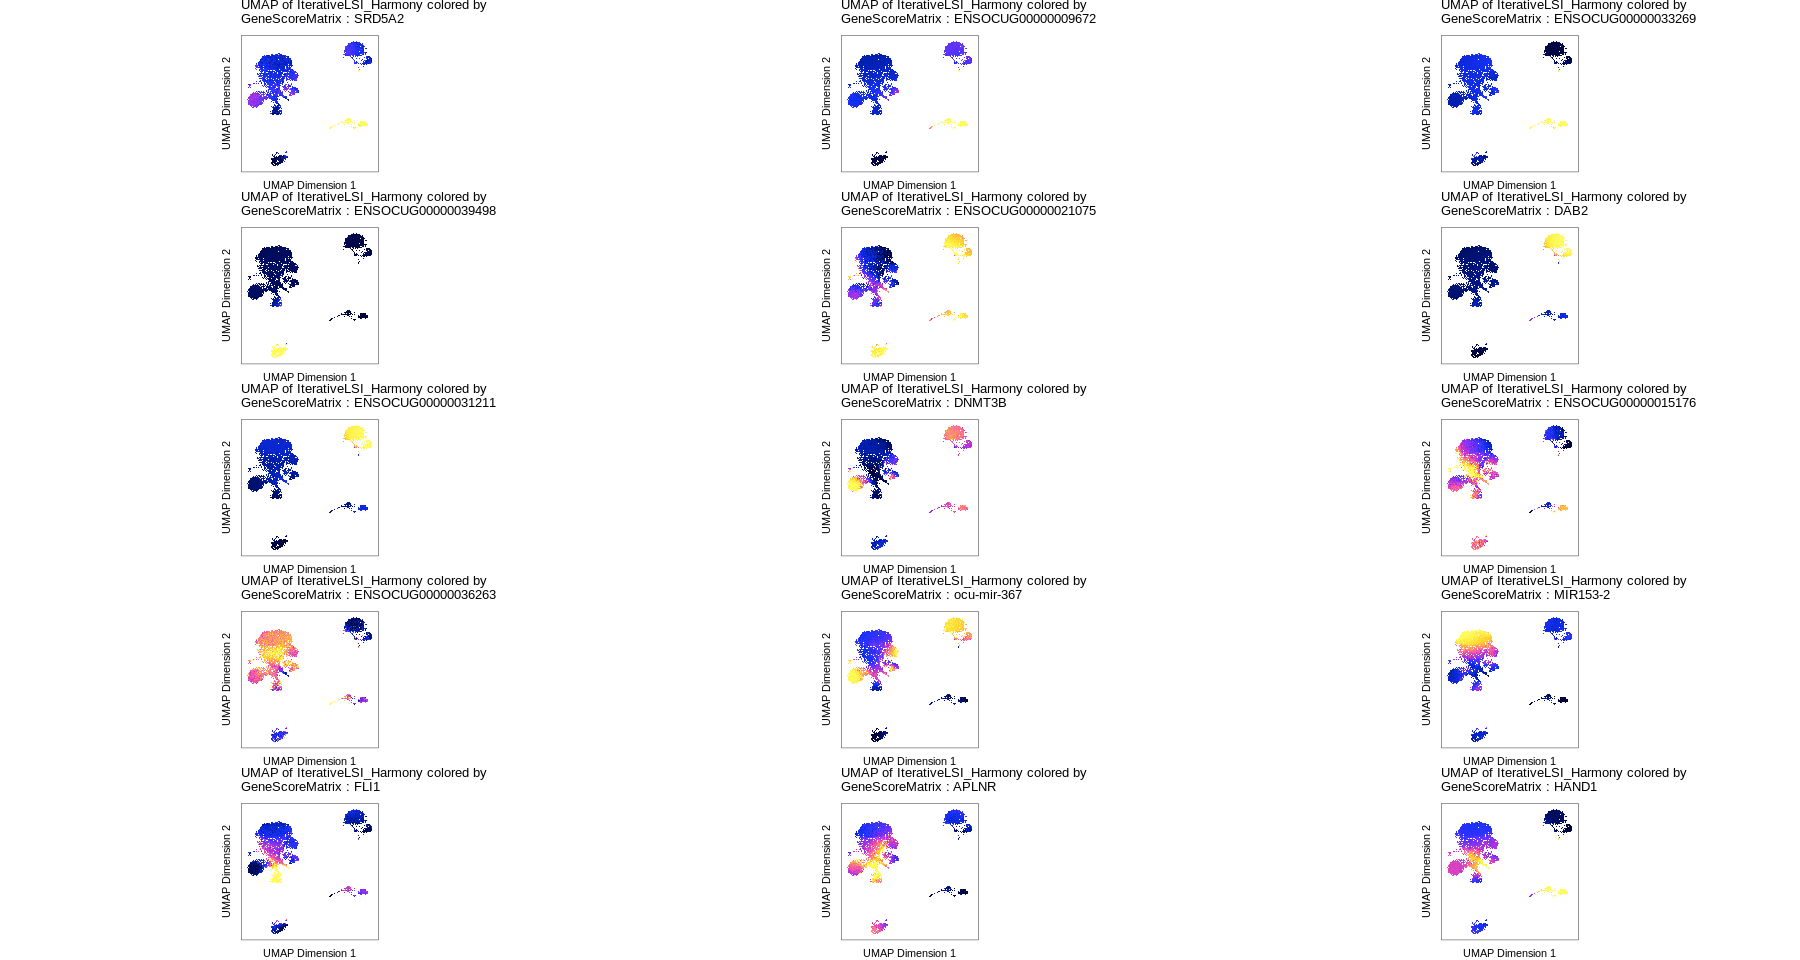

In [32]:
p2 <- lapply(p, function(x){
    x + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 6.5) +
    theme(plot.margin = unit(c(0, 0, 0, 0), "cm")) +
    theme(
        axis.text.x=element_blank(), 
        axis.ticks.x=element_blank(), 
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank()
    )
})
do.call(cowplot::plot_grid, c(list(ncol = 3),p2))

In [43]:
ArchRProject.filt


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/0X_Rabbit_ATAC/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(16): Sample TSSEnrichment ... stage Clusters
numberOfCells(1): 20057
medianTSS(1): 3.749
medianFrags(1): 29854

In [44]:
genes

[1] "SRD5A2"             "ENSOCUG00000009672" "ENSOCUG00000033269"
 [4] "ENSOCUG00000039498" "ENSOCUG00000021075" "DAB2"              
 [7] "ENSOCUG00000031211" "DNMT3B"             "ENSOCUG00000015176"
[10] "ENSOCUG00000036263" "ocu-mir-367"        "MIR153-2"          
[13] "FLI1"               "APLNR"              "HAND1"

In [45]:
p <- plotBrowserTrack(
    ArchRProj = ArchRProject.filt, 
    groupBy = "Clusters", 
    geneSymbol = genes, 
    upstream = 50000,
    downstream = 50000
)

ArchR logging to : ArchRLogs/ArchR-plotBrowserTrack-3dce555c4a78a-Date-2021-11-26_Time-00-09-24.log
If there is an issue, please report to github with logFile!

2021-11-26 00:09:25 : Validating Region, 0.008 mins elapsed.



GRanges object with 0 ranges and 2 metadata columns:
   seqnames    ranges strand |     gene_id      symbol
      <Rle> <IRanges>  <Rle> | <character> <character>
  -------
  seqinfo: 22 sequences from an unspecified genome


ArchR logging successful to : ArchRLogs/ArchR-plotBrowserTrack-3dce555c4a78a-Date-2021-11-26_Time-00-09-24.log



In [56]:
p = plotBrowserTrack(
    ArchRProj = ArchRProject.filt, 
    groupBy = "Clusters", 
    geneSymbol = 'NA_ENSOCUG00000036263', 
    upstream = 5000,
    downstream = 5000
)

ArchR logging to : ArchRLogs/ArchR-plotBrowserTrack-3dce533466c6f-Date-2021-11-26_Time-00-14-20.log
If there is an issue, please report to github with logFile!

2021-11-26 00:14:21 : Validating Region, 0.025 mins elapsed.



GRanges object with 1 range and 2 metadata columns:
      seqnames              ranges strand |            gene_id
         <Rle>           <IRanges>  <Rle> |        <character>
  [1]        1 145237557-145238510      + | ENSOCUG00000036263
                     symbol
                <character>
  [1] NA_ENSOCUG00000036263
  -------
  seqinfo: 22 sequences from an unspecified genome


2021-11-26 00:14:21 : Adding Bulk Tracks (1 of 1), 0.027 mins elapsed.

Getting Region From Arrow Files 1 of 8

Getting Region From Arrow Files 2 of 8

Getting Region From Arrow Files 3 of 8

Getting Region From Arrow Files 4 of 8

Getting Region From Arrow Files 5 of 8

Getting Region From Arrow Files 6 of 8

Getting Region From Arrow Files 7 of 8

Getting Region From Arrow Files 8 of 8

Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
2021-11-26 00:14:29 : Adding Gene Tracks (1 of 1), 0.156 mins elapsed.

Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
2021-11-26 00:14:29 : Plotting, 0.158 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-plotBrowserTrack-3dce533466c6f-Date-2021-11-26_Time-00-14-20.log



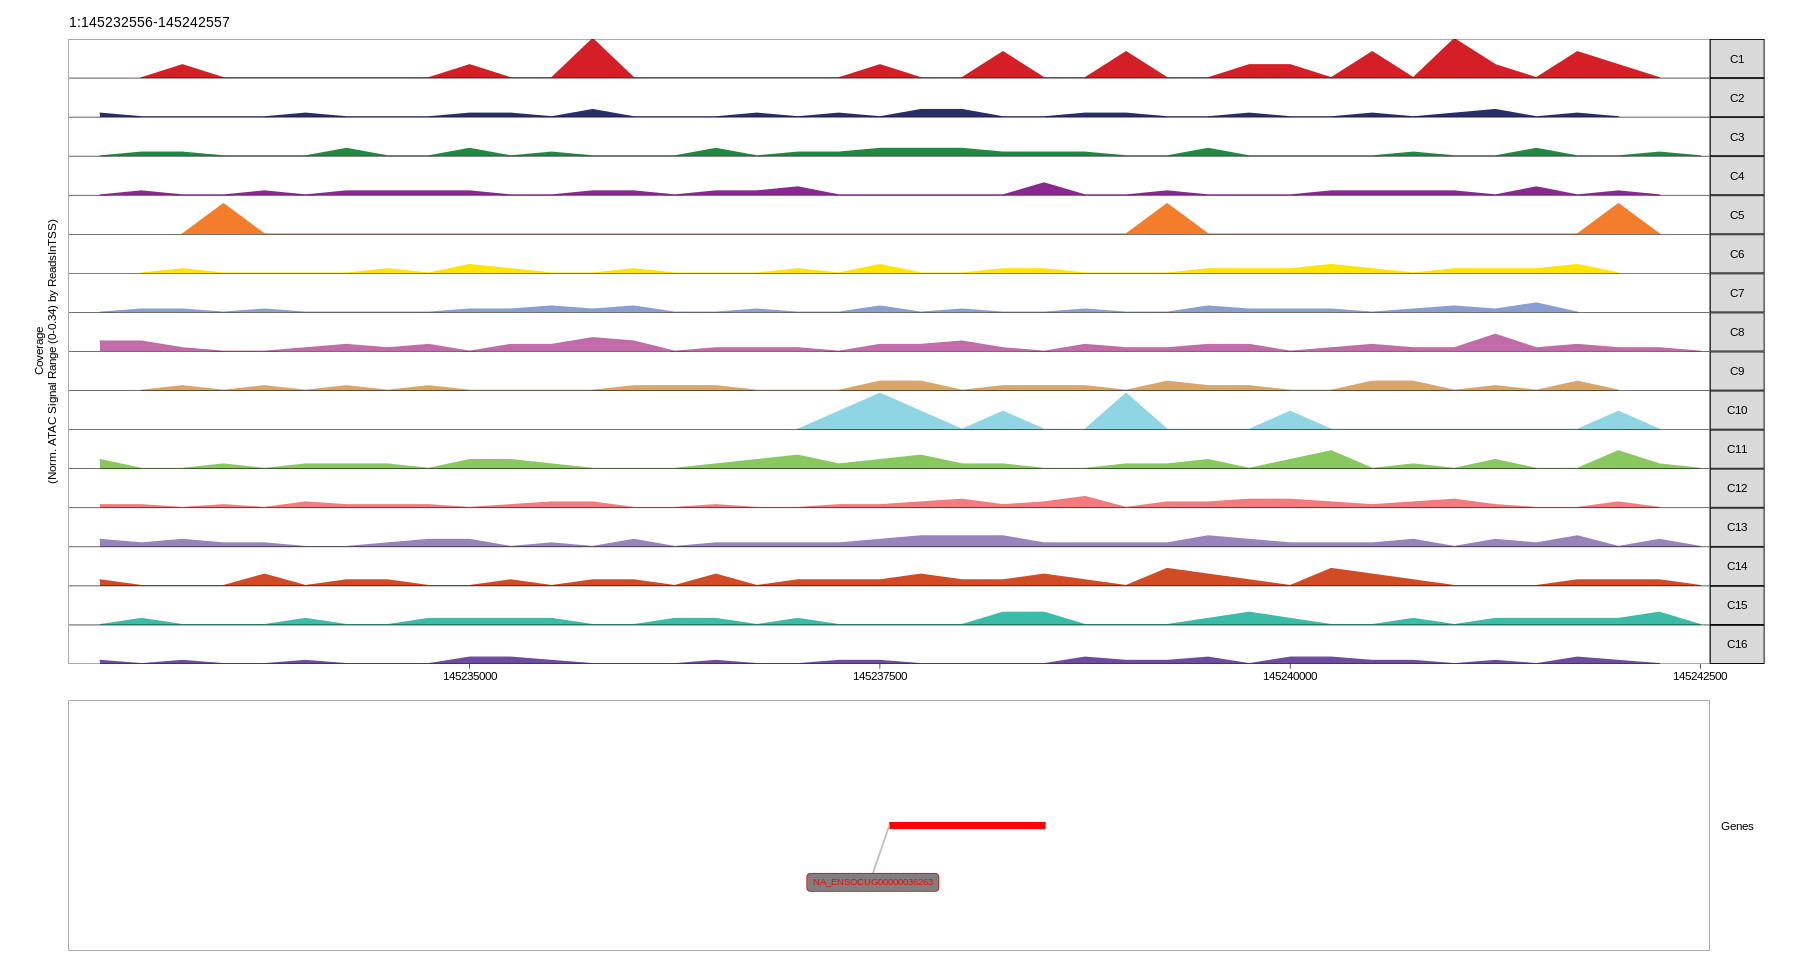

In [57]:
grid::grid.newpage()
grid::grid.draw(p[[1]])

In [35]:
lapply(p, function(x){
grid::grid.newpage()
grid::grid.draw(x)})

named list()

ERROR: Error in UseMethod("grid.draw"): no applicable method for 'grid.draw' applied to an object of class "list"
